# PDE: some random PDE

$$
\begin{cases}
\frac{\partial u}{\partial x}  = 2 \\
u(0,y) = y
\end{cases}
$$

Solution:
$$
u(x,y) = 2x + y
$$

In [1]:
# imports
# numpy
import numpy as np

# torch
import torch
import torch.nn as nn
import torch.optim as optim

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
#sns.set_theme(style="whitegrid")

In [2]:
# domain definition:
x_dom = torch.linspace(-5, 5, 100)
y_dom = torch.linspace(-5, 5, 100)
xy_dom = torch.cartesian_prod(x_dom, y_dom)

# move data to gpu
xy_dom = xy_dom.to("cuda:0")
xy_dom.requires_grad = True # need to specify


In [3]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),   # Input layer with 2 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for u(x,y)
        )

    def forward(self, X):
        return self.net(X)
    
    # Define the Poisson equation loss function
    def pde_loss(self, X):
        
        # compute estimation for function value
        u = self.forward(X)

        # get auxiliary tensor for gradient function
        vector = torch.ones_like(u)
        vector.to("cuda")

        # compute derivatives (gradient)
        u_X = torch.autograd.grad(u, X, grad_outputs=vector, create_graph=True)[0]
        u_x = u_X[:,0]
        u_y = u_X[:,1]
        
        # residue function
        f = (u_x - 2)**2

        return torch.mean(f)

    def boundary_loss(self):

        y_sample = torch.linspace(-5, 5, 100)
        X = torch.zeros([y_sample.shape[0], 2])
        X[:,1] = y_sample
        X = X.detach().to("cuda")
        
        u = self.forward(X)

        residue = (X[:,1].reshape(y_sample.shape[0], 1) - u)**2

        return torch.mean(residue)

In [4]:
# Create PINN model and move to gpu
model = PINN().to(torch.device("cuda:0"))

# optimizer
optimizer = optim.Adam(params=model.parameters(), lr=5e-4)

# loss tracking
losses = []

# Training loop
epochs = 20000
for epoch in range(epochs):

    # zero grad
    optimizer.zero_grad()

    # extimation of output not needed
    # u_est = model(xy_dom)

    loss = torch.mean(model.pde_loss(xy_dom)) + torch.mean(model.boundary_loss())

    # Backpropagation
    loss.backward()
    losses.append(torch.log(loss).item())
    optimizer.step()               
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")

Epoch [0/20000], Loss: 13.223026275634766
Epoch [1000/20000], Loss: 0.034633830189704895
Epoch [2000/20000], Loss: 0.00231731915846467
Epoch [3000/20000], Loss: 0.00047629085020162165
Epoch [4000/20000], Loss: 0.00016378004511352628
Epoch [5000/20000], Loss: 7.79595720814541e-05
Epoch [6000/20000], Loss: 4.4463926315074787e-05
Epoch [7000/20000], Loss: 3.356705201440491e-05
Epoch [8000/20000], Loss: 1.9975766917923465e-05
Epoch [9000/20000], Loss: 1.296442042075796e-05
Epoch [10000/20000], Loss: 0.00040725688450038433
Epoch [11000/20000], Loss: 7.212191576400073e-06
Epoch [12000/20000], Loss: 5.676181444869144e-06
Epoch [13000/20000], Loss: 6.2927256294642575e-06
Epoch [14000/20000], Loss: 3.4236154533573426e-06
Epoch [15000/20000], Loss: 2.812752063618973e-05
Epoch [16000/20000], Loss: 2.233564146081335e-06
Epoch [17000/20000], Loss: 1.7499023670097813e-06
Epoch [18000/20000], Loss: 1.5892201190581545e-05
Epoch [19000/20000], Loss: 1.132805846282281e-05


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


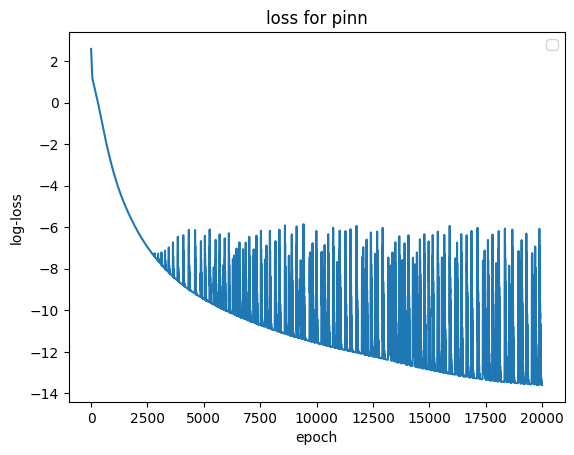

In [5]:
plt.figure()
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('log-loss')
plt.title('loss for pinn')
plt.legend()
plt.show()

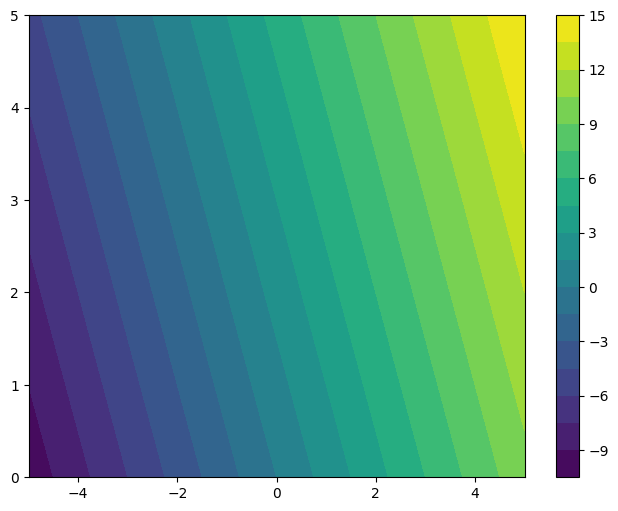

In [6]:
x = np.linspace(-5, 5, 100)
y = np.linspace(0, 5, 100)

X,Y = np.meshgrid(x, y)
data = np.vstack([X.ravel(), Y.ravel()])

pinn_model = model.to("cpu")

u_pinn = np.zeros_like(X)
u_pinn_log = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_pinn[i,j] = pinn_model(torch.Tensor([X[i,j],Y[i,j]]))
        u_pinn_log[i,j] = torch.log(torch.abs(pinn_model(torch.Tensor([X[i,j],Y[i,j]]))))

plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_pinn.reshape(X.shape), levels=20)
plt.colorbar()
plt.show()

/tmp/ipykernel_1670591/2245773606.py:8: RuntimeWarning: divide by zero encountered in log
  u_analytic_log[i,j] = np.log(np.abs(2*X[i,j]+Y[i,j]))


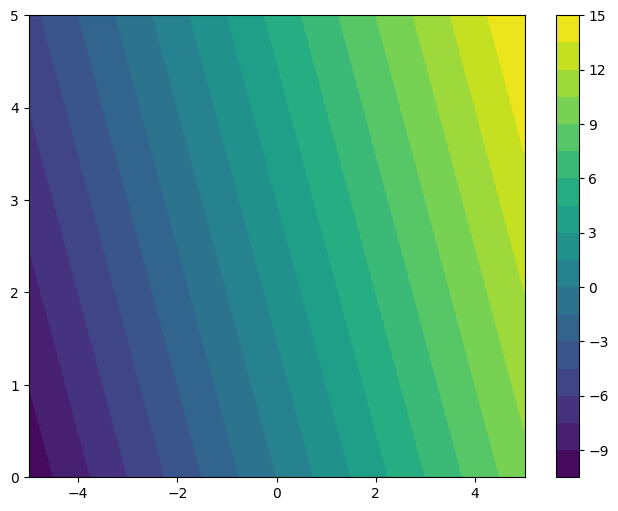

In [7]:
u_analytic = np.zeros_like(X)
u_analytic_log = np.zeros_like(X)


for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        u_analytic[i,j] = 2*X[i,j]+Y[i,j]
        u_analytic_log[i,j] = np.log(np.abs(2*X[i,j]+Y[i,j]))

plt.figure(figsize=(8,6))
plt.contourf(X, Y, u_analytic.reshape(X.shape), levels=20)
plt.colorbar()
plt.show()

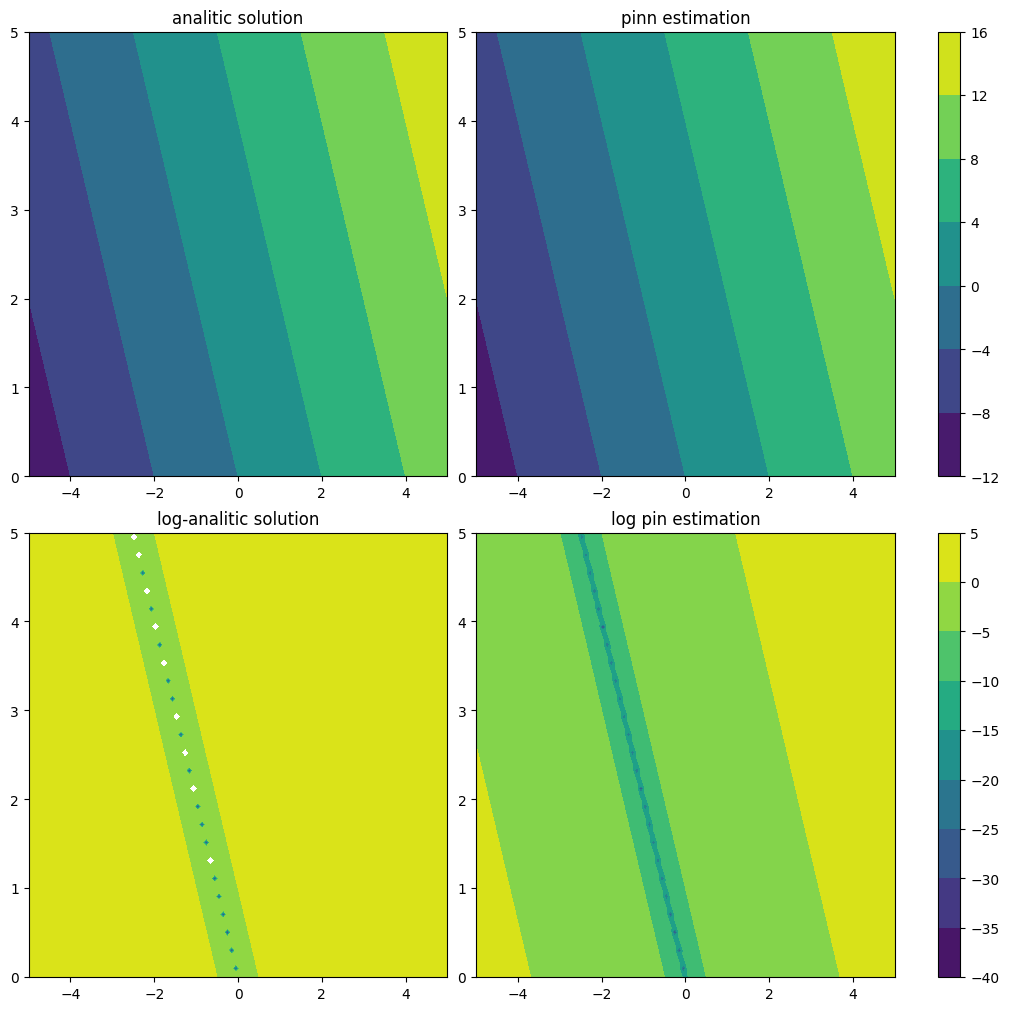

In [17]:
fig, axs = plt.subplot_mosaic([["anal_lin", "pinn_lin"],["anal_log", "pinn_log"]], figsize=(10,10), layout="constrained")
contourf_dict = {}

contourf_dict["anal_lin"] = axs["anal_lin"].contourf(X,Y, u_analytic)
contourf_dict["anal_log"] = axs["anal_log"].contourf(X,Y, u_analytic_log)
contourf_dict["pinn_lin"] = axs["pinn_lin"].contourf(X,Y, u_pinn)
contourf_dict["pinn_log"] = axs["pinn_log"].contourf(X,Y, u_pinn_log)
axs["anal_lin"].set_title("analitic solution")
axs["anal_log"].set_title("log-analitic solution")
axs["pinn_lin"].set_title("pinn estimation")
axs["pinn_log"].set_title("log pin estimation")

fig.colorbar(contourf_dict["anal_lin"], ax=[axs["anal_lin"], axs["pinn_lin"]])
fig.colorbar(contourf_dict["anal_log"], ax=[axs["anal_log"], axs["pinn_log"]])

fig.show()